In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from Noise_functions import *
from PC_functions import *
from DCN_functions import *
from IO_functions import *
from Noise_PC_Synapses_functions import *
from PC_DCN_Synapses_functions import *
from DCN_IO_Synapses_functions import *
from IO_PC_Synapses_functions import *
from Other_synapses import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from Input_func import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Frozen_data = sio.loadmat('Data/'+datetime.datetime.now().strftime("%m-%d")+'/Frozen.mat', squeeze_me=True)
Params, Noise_frozen, Values, Synaps = Read_Input(Frozen_data)
###################################################################
######################## Initial Parameters #######################
###################################################################
dt = Params.dt
dt_rec = Params.dt_rec
width = Params.width
tau_noise = Params.tau_noise
exp_run = Params.exp_run
N_Noise = Params.N_Noise
N_Cells_PC = Params.N_Cells_PC
N_Cells_DCN = Params.N_Cells_DCN
N_Cells_IO = Params.N_Cells_IO
N_Copy = Params.N_Copy
N_Copy_order = Params.N_Copy_order
###################################################################
########################## Cell Values ############################
###################################################################
Noise_I = Noise_frozen.Noise_I
I_recorded = Noise_frozen.I_recorded
period = Noise_frozen.period
PC_Values = Values.PC_Values
DCN_Values = Values.DCN_Values
IO_Values = Values.IO_Values
IO_thresh = Values.IO_thresh
eqs_IO_syn = Values.eqs_IO_syn
rate_meas = Values.rate_meas
rate_meas_out = Values.rate_meas_out
tau_presyn = Values.tau_presyn
tau_thresh_M = 10*ms#Values.tau_thresh_M
sine_amplitude_presyn = Values.sine_amplitude_presyn
sine_frequency_presyn = Values.sine_frequency_presyn
eqs_syn_bcm_s_n_pc = Values.eqs_syn_bcm_s_n_pc
eqs_syn_IO_PC_pre = Values.eqs_syn_IO_PC_pre
###################################################################
###################### Synapses Values ############################
###################################################################
IO_Copy_Synapse_Targets = Synaps.IO_Copy_Synapse_Targets
Noise_PC_Synapse_Sources = Synaps.Noise_PC_Synapse_Sources
Noise_PC_Synapse_Targets = Synaps.Noise_PC_Synapse_Targets 
Noise_PC_Synapse_Weights = Synaps.Noise_PC_Synapse_Weights
PC_DCN_Synapse_Sources = Synaps.PC_DCN_Synapse_Sources
PC_DCN_Synapse_Targets = Synaps.PC_DCN_Synapse_Targets
DCN_IO_Synapse_Sources = Synaps.DCN_IO_Synapse_Sources 
DCN_IO_Synapse_Targets = Synaps.DCN_IO_Synapse_Targets 
IO_PC_Synapse_Sources = Synaps.IO_PC_Synapse_Sources
IO_PC_Synapse_Targets = Synaps.IO_PC_Synapse_Targets


def presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec):
    eqs_presyn = '''
            rho_presyn = ampli*noise_in: Hz
            noise_in : 1
            ampli : Hz
            '''
    Input_presyn = NeuronGroup(N_Noise, eqs_presyn, threshold='True', method='euler', dt=dt)
    Input_presyn_statemon = StateMonitor(Input_presyn, variables=['rho_presyn'], record=True, dt=dt_rec)
    ampli = rand_params(30,Hz,N_Noise,(5/N_Noise))
    for ii in range(0, N_Noise, 1):
        Input_presyn.ampli[ii] = ampli[ii]
    return Input_presyn, Input_presyn_statemon
###################################################################
###################################################################
############################## CELLS ##############################
###################################################################
###################################################################
############################## NOISE ##############################
###################################################################
Noise, Noise_statemon, Noise_extended, Noise_extended_statemon = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL ##########################
###################################################################
PC, PC_Statemon, PC_Spikemon, PC_rate = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################## DEEP CEREBELLAR NUCLEI CELLS ###################
###################################################################
DCN, DCN_Statemon, DCN_Spikemon, DCN_rate = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO ##################################
###################################################################
IO, IO_Statemon, IO_Spikemon, IO_rate = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
###################################################################
############################# PF ##################################
###################################################################
Input_presyn, Input_presyn_statemon = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate ################################
###################################################################
syn = rate_meas_func(rate_meas,PC,dt)
syn.connect(j='i')  
syn.subtract.delay = rate_meas_out  # delay the subtraction
###################################################################
############################# Copy ################################
###################################################################
conn_N_PC, mon_N_PC = conn_N_PC_No_BCM_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec) ## NO BCM Connection
###################################################################
###################################################################
############################## CELLS COUPLED ######################
###################################################################
###################################################################
############################## NOISE COUPLED ######################
###################################################################
Noise_Coupled, Noise_statemon_Coupled, Noise_extended_Coupled, Noise_extended_statemon_Coupled = Noise_neuron(N_Noise,I_recorded,period,dt,dt_rec)
###################################################################
########################## PURKINJE CELL COUPLED ##################
###################################################################
PC_Coupled, PC_Statemon_Coupled, PC_Spikemon_Coupled, PC_rate_Coupled = PC_neurons(N_Cells_PC,PC_Values,dt,dt_rec)
###################################################################
################ DEEP CEREBELLAR NUCLEI CELLS COUPLED #############
###################################################################
DCN_Coupled, DCN_Statemon_Coupled, DCN_Spikemon_Coupled, DCN_rate_Coupled = DCN_neurons(N_Cells_DCN,DCN_Values,dt,dt_rec)
###################################################################
############################# IO COUPLED ##########################
###################################################################
IO_Coupled, IO_Statemon_Coupled, IO_Spikemon_Coupled, IO_rate_Coupled = IO_neurons(N_Cells_IO,IO_Values,IO_thresh,dt,dt_rec)
IO_synapse_Coupled = IO_coup_syn(IO_Coupled,eqs_IO_syn) # create synaptic equations and apply full synaptic strength for second network
IO_synapse_Coupled.connect() # connect second network
###################################################################
############################# PF COUPLED ##########################
###################################################################
Input_presyn_Coupled, Input_presyn_statemon_Coupled = presyn_inp(N_Noise,sine_amplitude_presyn,sine_frequency_presyn, dt, dt_rec)
###################################################################
############################# Rate COUPLED ########################
###################################################################
syn_Coupled = rate_meas_func(rate_meas,PC_Coupled,dt)
syn_Coupled.connect(j='i')  
syn_Coupled.subtract.delay = rate_meas_out  # delay the subtraction 
###################################################################
############################# Copy COUPLED ########################
###################################################################
conn_N_PC_Coupled, mon_N_PC_Coupled = conn_N_PC_No_BCM_func(N_Copy, Noise_PC_Synapse_Weights, dt, dt_rec)
###################################################################
###################################################################
########################## SYNAPSES ###############################
###################################################################
###################################################################
########################## PC DCN Synapse #########################
###################################################################
PC_DCN_Synapse = PC_DCN_syn(PC,DCN,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
########################## DCN IO Synapse #########################
###################################################################
DCN_IO_Synapse = DCN_IO_syn(DCN,IO,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
########################## IO ConnPC Synapse ######################
###################################################################
S_IO_N = Synapses(IO, conn_N_PC, method='euler',dt=dt)  # where f is 
S_IO_N.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
########################### IO PC Synapse #########################
###################################################################
IO_PC_Synapse = Synapses(IO, PC, on_pre ='w +=(1.5*nA)', delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
######################### ConnPC PC Synapse #######################
###################################################################
S_N_PC = Synapses(conn_N_PC,PC, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
########################## ConnPC Noise Synapse ###################
###################################################################
S_PC_N = Synapses(conn_N_PC,Noise, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
############################# Copy rate ###########################
###################################################################
copy_rate = Synapses(Input_presyn, conn_N_PC, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
############################ Copy Noise ###########################
###################################################################
copy_noise = Synapses(Noise, conn_N_PC, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise.weight = Noise_PC_Synapse_Weights
###################################################################
########################## PC Rate Synapse ########################
###################################################################
S_PC_rate = Synapses(PC,conn_N_PC, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)

presyn_Noise_syn = Synapses(Noise_extended, Input_presyn, 'noise_in_post = I_pre/nA : 1 (summed)',method='euler',dt=dt)  # where f is 
presyn_Noise_syn.connect(j = 'i')
###################################################################
###################################################################
####################### SYNAPSES COUPLED ##########################
###################################################################
###################################################################
#################### PC DCN Synapse COUPLED #######################
###################################################################
PC_DCN_Synapse_Coupled = PC_DCN_syn(PC_Coupled,DCN_Coupled,N_Cells_PC,N_Cells_DCN,dt,dt_rec)
PC_DCN_Synapse_Coupled.connect(i=PC_DCN_Synapse_Sources,j=PC_DCN_Synapse_Targets)
###################################################################
#################### DCN IO Synapse COUPLED #######################
###################################################################
DCN_IO_Synapse_Coupled = DCN_IO_syn(DCN_Coupled,IO_Coupled,N_Cells_DCN,N_Cells_IO,dt,dt_rec)
DCN_IO_Synapse_Coupled.connect(i=DCN_IO_Synapse_Sources,j=DCN_IO_Synapse_Targets)
###################################################################
################# IO ConnPC Synapse COUPLED #######################
###################################################################
S_IO_N_Coupled = Synapses(IO_Coupled, conn_N_PC_Coupled, method='euler',dt=dt)  # where f is 
S_IO_N_Coupled.connect(i=IO_PC_Synapse_Sources, j=IO_Copy_Synapse_Targets)
###################################################################
##################### IO PC Synapse COUPLED #######################
###################################################################
IO_PC_Synapse_Coupled = Synapses(IO_Coupled, PC_Coupled, on_pre ='w +=(1.5*nA)', delay=2*ms,method = 'euler',dt=dt)
IO_PC_Synapse_Coupled.connect(i=IO_PC_Synapse_Sources,j=IO_PC_Synapse_Targets)
###################################################################
################# ConnPC PC Synapse COUPLED #######################
###################################################################
S_N_PC_Coupled = Synapses(conn_N_PC_Coupled,PC_Coupled, eqs_syn_bcm_s_n_pc, method='euler',dt=dt)
S_N_PC_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Targets)
###################################################################
############## ConnPC Noise Synapse COUPLED #######################
###################################################################
S_PC_N_Coupled = Synapses(conn_N_PC_Coupled,Noise_Coupled, 'weight_post = new_weight_pre : 1 (summed)', method='euler',dt=dt)
S_PC_N_Coupled.connect(i=N_Copy_order, j = Noise_PC_Synapse_Sources)
###################################################################
######################### Copy rate COUPLED #######################
###################################################################
copy_rate_Coupled = Synapses(Input_presyn_Coupled, conn_N_PC_Coupled, 'rho_PF_post = rho_presyn_pre : Hz (summed)', method='euler',dt=dt)
copy_rate_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
###################################################################
######################## Copy Noise COUPLED #######################
###################################################################
copy_noise_Coupled = Synapses(Noise_Coupled, conn_N_PC_Coupled, 'I_post = I_pre : amp (summed)', method='euler', dt=dt)
copy_noise_Coupled.connect(i = Noise_PC_Synapse_Sources, j=N_Copy_order)
copy_noise_Coupled.weight = Noise_PC_Synapse_Weights
###################################################################
################### PC Rate Synapse COUPLED #######################
###################################################################
S_PC_rate_Coupled = Synapses(PC_Coupled,conn_N_PC_Coupled, 'rho_PC_post = New_recent_rate_pre : Hz (summed)', method='euler',dt=dt)
S_PC_rate_Coupled.connect(i=Noise_PC_Synapse_Targets, j =N_Copy_order)

presyn_Noise_syn_Coupled = Synapses(Noise_extended_Coupled, Input_presyn_Coupled, 'noise_in_post = I_pre/nA : 1 (summed)',method='euler',dt=dt)  # where f is 
presyn_Noise_syn_Coupled.connect(j = 'i')

ld: warning: -pie being ignored. It is only used when linking a main executable
ld: unsupported tapi file type '!tapi-tbd' in YAML file '/Library/Developer/CommandLineTools/SDKs/MacOSX.sdk/usr/lib/libSystem.tbd' for architecture x86_64
clang-10: error: linker command failed with exit code 1 (use -v to see invocation)
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-apple-darwin13.4.0-clang++' failed with exit status 1 (LinkError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


CPU times: user 3.23 s, sys: 633 ms, total: 3.86 s
Wall time: 6.13 s


In [2]:
###################################################################
IO.g_Ca_l =  0.375*mS/cm**2
IO_Coupled.g_Ca_l =  0.4*mS/cm**2

IO.sigma_OU = 0.5*uA/cm**2
IO_Coupled.sigma_OU = 0.5*uA/cm**2

a_OU = 1.5
b_OU = .5

IO.I_OU = a_OU*uA/cm**2
IO.I0_OU = a_OU*uA/cm**2

IO_Coupled.I_OU = a_OU*uA/cm**2
IO_Coupled.I0_OU = a_OU*uA/cm**2
###################################################################
########################### RUN ###################################
###################################################################

run(exp_run,report='text') # Report on the simulation

Starting simulation at t=0. s for a duration of 120. s
118.675 ms (0%) simulated in 10s, estimated 2h 48m 24s remaining.
244.5 ms (0%) simulated in 20s, estimated 2h 43m 17s remaining.
0.3651 s (0%) simulated in 30s, estimated 2h 43m 52s remaining.
0.491275 s (0%) simulated in 40s, estimated 2h 42m 12s remaining.
0.615825 s (0%) simulated in 50s, estimated 2h 41m 35s remaining.
0.742825 s (0%) simulated in 1m 0s, estimated 2h 40m 34s remaining.
0.873725 s (0%) simulated in 1m 10s, estimated 2h 39m 5s remaining.
0.99945 s (0%) simulated in 1m 20s, estimated 2h 38m 47s remaining.
1.126875 s (0%) simulated in 1m 30s, estimated 2h 38m 15s remaining.
1.2573 s (1%) simulated in 1m 40s, estimated 2h 37m 26s remaining.
1.3856 s (1%) simulated in 1m 50s, estimated 2h 36m 58s remaining.
1.522675 s (1%) simulated in 2m 0s, estimated 2h 35m 38s remaining.
1.664075 s (1%) simulated in 2m 10s, estimated 2h 34m 6s remaining.
1.8045 s (1%) simulated in 2m 20s, estimated 2h 32m 51s remaining.
1.945025 

16.87945 s (14%) simulated in 20m 0s, estimated 2h 2m 12s remaining.
17.008775 s (14%) simulated in 20m 10s, estimated 2h 2m 7s remaining.
17.163575 s (14%) simulated in 20m 20s, estimated 2h 1m 50s remaining.
17.322425 s (14%) simulated in 20m 30s, estimated 2h 1m 31s remaining.
17.481325 s (14%) simulated in 20m 40s, estimated 2h 1m 13s remaining.
17.6406 s (14%) simulated in 20m 50s, estimated 2h 0m 54s remaining.
17.798325 s (14%) simulated in 21m 0s, estimated 2h 0m 36s remaining.
17.9552 s (14%) simulated in 21m 10s, estimated 2h 0m 18s remaining.
18.106025 s (15%) simulated in 21m 20s, estimated 2h 0m 4s remaining.
18.254775 s (15%) simulated in 21m 30s, estimated 1h 59m 51s remaining.
18.401275 s (15%) simulated in 21m 40s, estimated 1h 59m 38s remaining.
18.566575 s (15%) simulated in 21m 50s, estimated 1h 59m 17s remaining.
18.721275 s (15%) simulated in 22m 0s, estimated 1h 59m 2s remaining.
18.878125 s (15%) simulated in 22m 10s, estimated 1h 58m 45s remaining.
19.031125 s 

34.57605 s (28%) simulated in 39m 20s, estimated 1h 37m 11s remaining.
34.7208 s (28%) simulated in 39m 30s, estimated 1h 37m 2s remaining.
34.86715 s (29%) simulated in 39m 40s, estimated 1h 36m 52s remaining.
35.012525 s (29%) simulated in 39m 50s, estimated 1h 36m 42s remaining.
35.149925 s (29%) simulated in 40m 0s, estimated 1h 36m 34s remaining.
35.290325 s (29%) simulated in 40m 10s, estimated 1h 36m 25s remaining.
35.43025 s (29%) simulated in 40m 20s, estimated 1h 36m 17s remaining.
35.575625 s (29%) simulated in 40m 30s, estimated 1h 36m 7s remaining.
35.7243 s (29%) simulated in 40m 40s, estimated 1h 35m 57s remaining.
35.869125 s (29%) simulated in 40m 50s, estimated 1h 35m 47s remaining.
36.007 s (30%) simulated in 41m 0s, estimated 1h 35m 39s remaining.
36.1509 s (30%) simulated in 41m 10s, estimated 1h 35m 29s remaining.
36.282425 s (30%) simulated in 41m 20s, estimated 1h 35m 23s remaining.
36.427525 s (30%) simulated in 41m 30s, estimated 1h 35m 13s remaining.
36.57442

50.5817 s (42%) simulated in 58m 40s, estimated 1h 20m 31s remaining.
50.72875 s (42%) simulated in 58m 50s, estimated 1h 20m 21s remaining.
50.874675 s (42%) simulated in 59m 0s, estimated 1h 20m 10s remaining.
51.021025 s (42%) simulated in 59m 10s, estimated 1h 20m 0s remaining.
51.1669 s (42%) simulated in 59m 20s, estimated 1h 19m 50s remaining.
51.303575 s (42%) simulated in 59m 30s, estimated 1h 19m 41s remaining.
51.44945 s (42%) simulated in 59m 40s, estimated 1h 19m 30s remaining.
51.5954 s (42%) simulated in 59m 50s, estimated 1h 19m 20s remaining.
51.7408 s (43%) simulated in 1h 0m 0s, estimated 1h 19m 10s remaining.
51.87195 s (43%) simulated in 1h 0m 10s, estimated 1h 19m 2s remaining.
52.002025 s (43%) simulated in 1h 0m 20s, estimated 1h 18m 54s remaining.
52.131225 s (43%) simulated in 1h 0m 30s, estimated 1h 18m 46s remaining.
52.2634 s (43%) simulated in 1h 0m 40s, estimated 1h 18m 38s remaining.
52.39655 s (43%) simulated in 1h 0m 50s, estimated 1h 18m 30s remaining

65.977325 s (54%) simulated in 1h 17m 31s, estimated 1h 3m 28s remaining.
66.123575 s (55%) simulated in 1h 17m 41s, estimated 1h 3m 18s remaining.
66.26995 s (55%) simulated in 1h 17m 51s, estimated 1h 3m 7s remaining.
66.4164 s (55%) simulated in 1h 18m 1s, estimated 1h 2m 57s remaining.
66.56415 s (55%) simulated in 1h 18m 11s, estimated 1h 2m 46s remaining.
66.709075 s (55%) simulated in 1h 18m 21s, estimated 1h 2m 36s remaining.
66.8564 s (55%) simulated in 1h 18m 31s, estimated 1h 2m 25s remaining.
67.003 s (55%) simulated in 1h 18m 41s, estimated 1h 2m 14s remaining.
67.149975 s (55%) simulated in 1h 18m 51s, estimated 1h 2m 4s remaining.
67.297075 s (56%) simulated in 1h 19m 1s, estimated 1h 1m 53s remaining.
67.443925 s (56%) simulated in 1h 19m 11s, estimated 1h 1m 42s remaining.
67.5912 s (56%) simulated in 1h 19m 21s, estimated 1h 1m 32s remaining.
67.738075 s (56%) simulated in 1h 19m 31s, estimated 1h 1m 21s remaining.
67.885425 s (56%) simulated in 1h 19m 41s, estimated 

81.6929 s (68%) simulated in 2h 21m 39s, estimated 1h 6m 26s remaining.
81.8395 s (68%) simulated in 2h 21m 49s, estimated 1h 6m 8s remaining.
81.9863 s (68%) simulated in 2h 21m 59s, estimated 1h 5m 50s remaining.
82.13385 s (68%) simulated in 2h 22m 9s, estimated 1h 5m 32s remaining.
82.281425 s (68%) simulated in 2h 22m 19s, estimated 1h 5m 15s remaining.
82.427425 s (68%) simulated in 2h 22m 29s, estimated 1h 4m 57s remaining.
82.574625 s (68%) simulated in 2h 22m 39s, estimated 1h 4m 39s remaining.
82.721475 s (68%) simulated in 2h 22m 49s, estimated 1h 4m 22s remaining.
82.8251 s (69%) simulated in 2h 22m 59s, estimated 1h 4m 11s remaining.
82.9487 s (69%) simulated in 2h 23m 9s, estimated 1h 3m 57s remaining.
83.1075 s (69%) simulated in 2h 23m 19s, estimated 1h 3m 37s remaining.
83.2374 s (69%) simulated in 2h 23m 29s, estimated 1h 3m 22s remaining.
83.36805 s (69%) simulated in 2h 23m 39s, estimated 1h 3m 7s remaining.
83.52615 s (69%) simulated in 2h 23m 49s, estimated 1h 2m 

97.217775 s (81%) simulated in 3h 1m 14s, estimated 42m 28s remaining.
97.343425 s (81%) simulated in 3h 1m 24s, estimated 42m 13s remaining.
97.475175 s (81%) simulated in 3h 1m 34s, estimated 41m 58s remaining.
97.61305 s (81%) simulated in 3h 1m 44s, estimated 41m 41s remaining.
97.732725 s (81%) simulated in 3h 1m 54s, estimated 41m 27s remaining.
97.845875 s (81%) simulated in 3h 2m 4s, estimated 41m 14s remaining.
97.980075 s (81%) simulated in 3h 2m 14s, estimated 40m 57s remaining.
98.098475 s (81%) simulated in 3h 2m 24s, estimated 40m 44s remaining.
98.2347 s (81%) simulated in 3h 2m 34s, estimated 40m 27s remaining.
98.36815 s (81%) simulated in 3h 2m 44s, estimated 40m 11s remaining.
98.50415 s (82%) simulated in 3h 2m 54s, estimated 39m 55s remaining.
98.635825 s (82%) simulated in 3h 3m 4s, estimated 39m 39s remaining.
98.77205 s (82%) simulated in 3h 3m 14s, estimated 39m 23s remaining.
98.907425 s (82%) simulated in 3h 3m 24s, estimated 39m 7s remaining.
99.036075 s (82

112.364025 s (93%) simulated in 3h 20m 24s, estimated 13m 37s remaining.
112.481825 s (93%) simulated in 3h 20m 34s, estimated 13m 24s remaining.
112.620225 s (93%) simulated in 3h 20m 44s, estimated 13m 9s remaining.
112.762325 s (93%) simulated in 3h 20m 54s, estimated 12m 54s remaining.
112.896525 s (94%) simulated in 3h 21m 4s, estimated 12m 39s remaining.
113.031425 s (94%) simulated in 3h 21m 14s, estimated 12m 24s remaining.
113.169525 s (94%) simulated in 3h 21m 24s, estimated 12m 9s remaining.
113.307275 s (94%) simulated in 3h 21m 34s, estimated 11m 54s remaining.
113.442125 s (94%) simulated in 3h 21m 44s, estimated 11m 40s remaining.
113.58075 s (94%) simulated in 3h 21m 54s, estimated 11m 25s remaining.
113.720525 s (94%) simulated in 3h 22m 4s, estimated 11m 10s remaining.
113.861675 s (94%) simulated in 3h 22m 14s, estimated 10m 54s remaining.
113.999 s (94%) simulated in 3h 22m 24s, estimated 10m 39s remaining.
114.1289 s (95%) simulated in 3h 22m 34s, estimated 10m 25s

In [10]:
%%time
from read_data import *
Create_output("_No_BCM",width,Noise_statemon,Noise_extended_statemon,PC_Statemon,PC_Spikemon, PC_rate,DCN_Statemon,DCN_Spikemon, DCN_rate,IO_Statemon,IO_Spikemon,IO_rate,mon_N_PC,Noise_statemon_Coupled,Noise_extended_statemon_Coupled,PC_Statemon_Coupled,PC_Spikemon_Coupled, PC_rate_Coupled,DCN_Statemon_Coupled,DCN_Spikemon_Coupled,DCN_rate_Coupled,IO_Statemon_Coupled,IO_Spikemon_Coupled,IO_rate_Coupled,mon_N_PC_Coupled)

Successfully created the directory /Users/eliasmateofernandezsantoro/Documents/Erasmus MC/Papers/CerbellarLoopPaper/CerebellarLoop/Code/2021/June/4 


WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/numpy/core/_asarray.py:136: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  return array(a, dtype, copy=False, order=order, subok=True)
 [py.warnings]
  return array(a, dtype, copy=False, order=order, subok=True)



15:10
CPU times: user 14min 44s, sys: 20.7 s, total: 15min 5s
Wall time: 2min 24s


WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



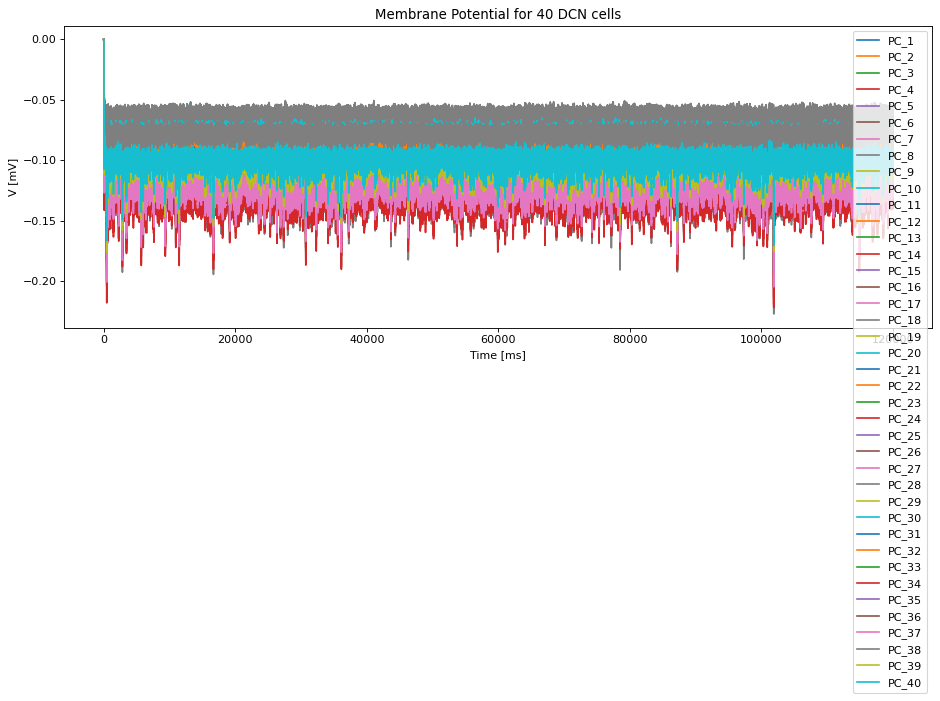

In [4]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_DCN):
    plot(IO_Statemon.t/ms,IO_Statemon.I_IO_DCN[ii]/(uA*cm**-2), label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_DCN)+" DCN cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



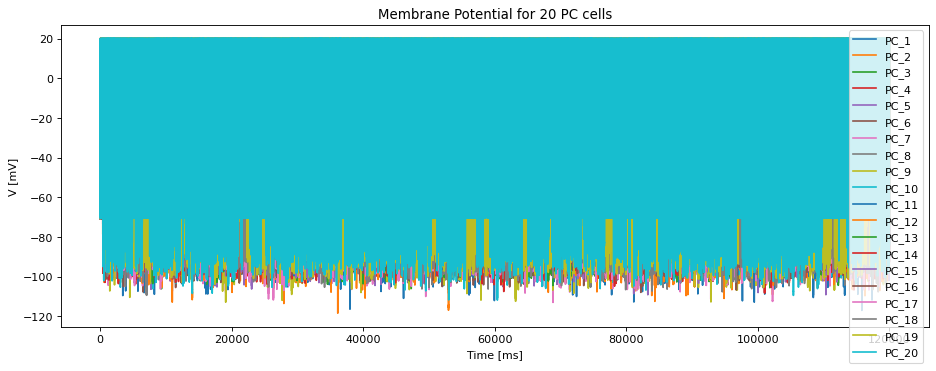

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



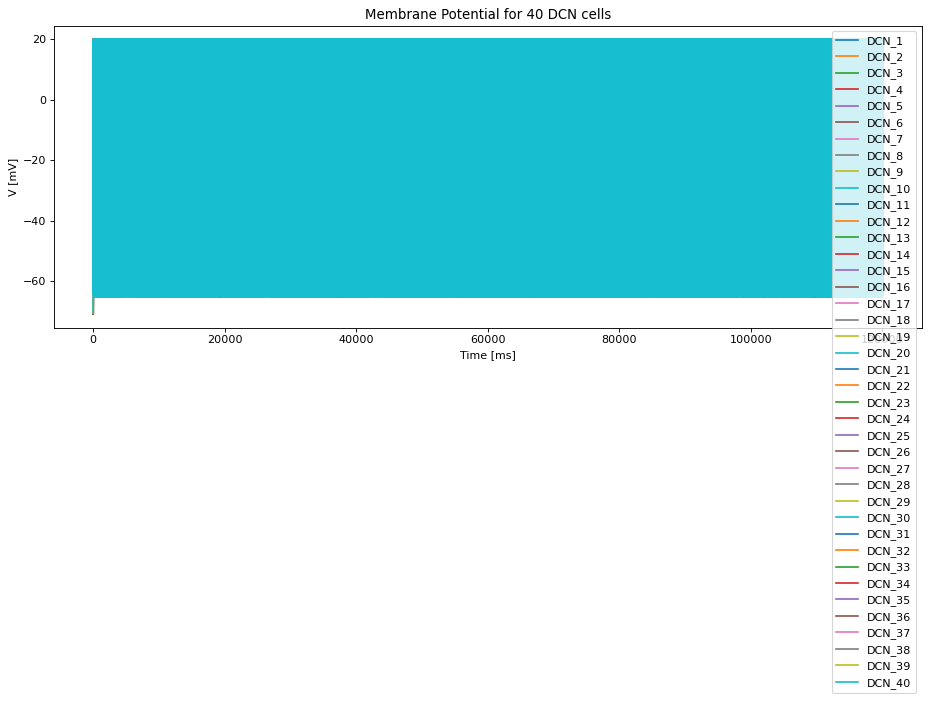

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



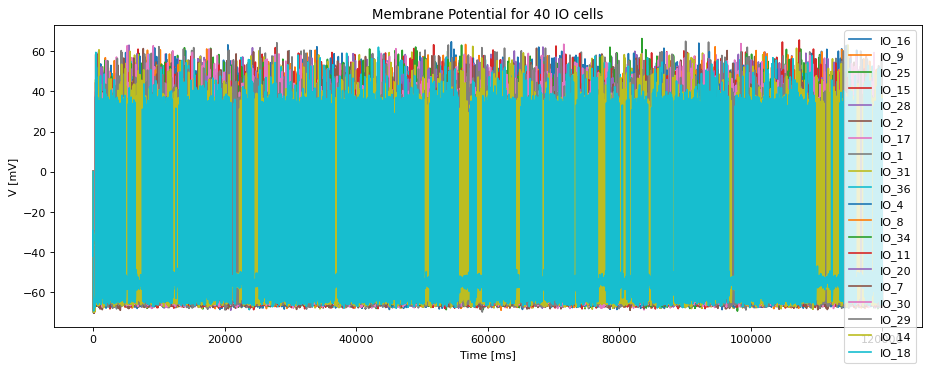

CPU times: user 8min 48s, sys: 4.77 s, total: 8min 53s
Wall time: 22min 56s


In [5]:
%%time
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm = PC_Statemon[ii].v[:]
    for t in PC_Spikemon.t:
        i = int(t / dt_rec)
        vm[i] = 20*mV
    plot(PC_Statemon.t/ms,vm/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" PC cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_DCN):
    vm2 = DCN_Statemon[ii].v[:]
    for t in DCN_Spikemon.t:
        i = int(t / dt_rec)
        vm2[i] = 20*mV
    plot(DCN_Statemon.t/ms,vm2/mV, label='DCN_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_DCN)+" DCN cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in IO_PC_Synapse_Sources:#range(0,N_Cells_DCN):
    plot(IO_Statemon.t/ms,IO_Statemon.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_DCN)+" IO cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



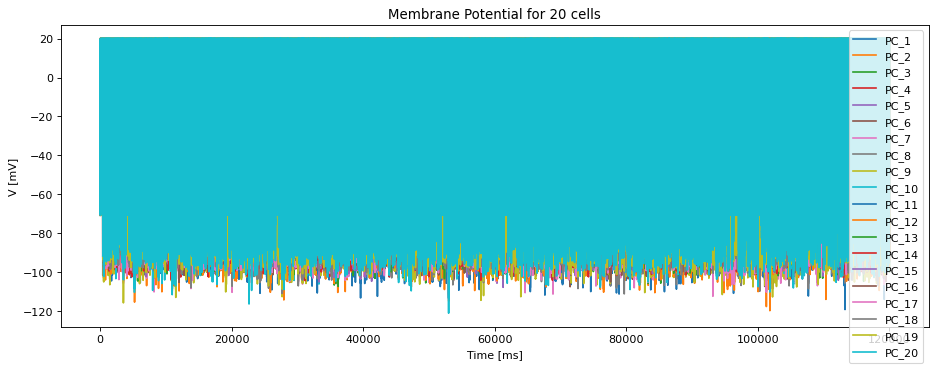

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



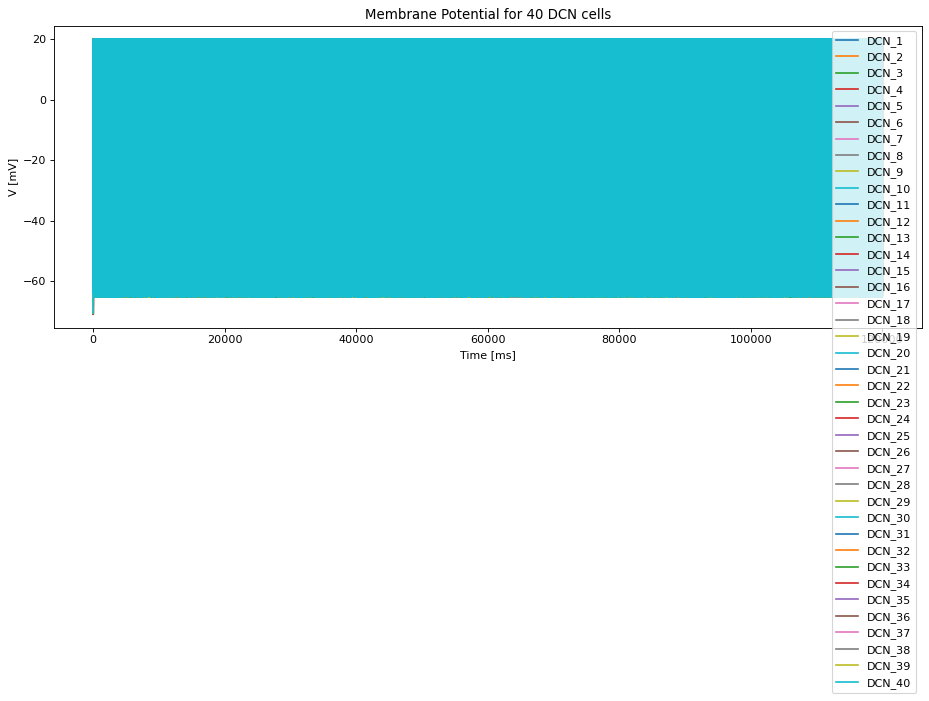

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



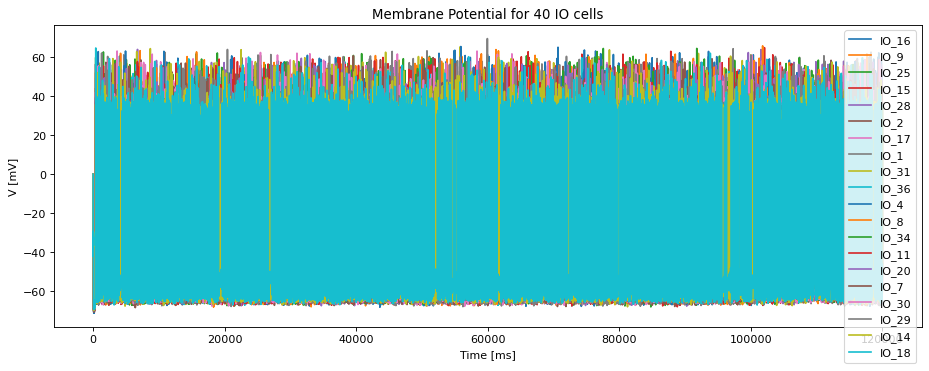

In [6]:

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_PC):
    vm_Coupled = PC_Statemon_Coupled[ii].v[:]
    for t in PC_Spikemon_Coupled.t:
        i = int(t / dt_rec)
        vm_Coupled[i] = 20*mV
    plot(PC_Statemon_Coupled.t/ms,vm_Coupled/mV, label='PC_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_PC)+" cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in range(0,N_Cells_DCN):
    vm2 = DCN_Statemon_Coupled[ii].v[:]
    for t in DCN_Spikemon_Coupled.t:
        i = int(t / dt_rec)
        vm2[i] = 20*mV
    plot(DCN_Statemon_Coupled.t/ms,vm2/mV, label='DCN_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_DCN)+" DCN cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in IO_PC_Synapse_Sources:#range(0,N_Cells_DCN):
    plot(IO_Statemon_Coupled.t/ms,IO_Statemon_Coupled.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_DCN)+" IO cells")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

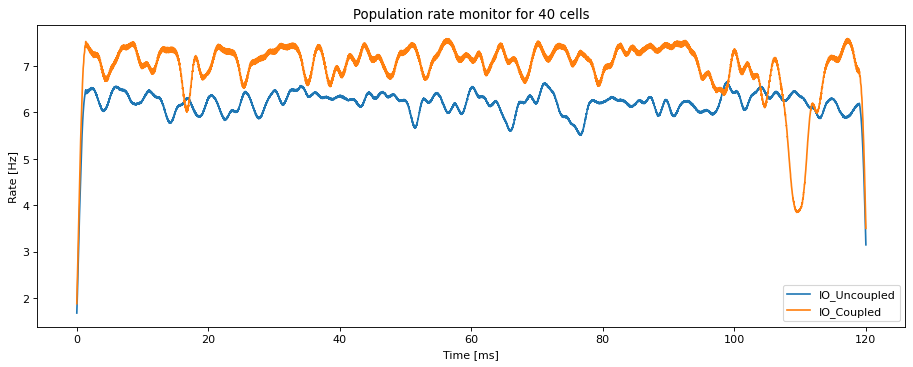

In [7]:
width = 500*ms
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
plot(IO_rate.t, IO_rate.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Uncoupled')
plot(IO_rate_Coupled.t, IO_rate_Coupled.smooth_rate(window='gaussian', width=width)/Hz, label='IO_Coupled')
title('Population rate monitor for '+str(N_Cells_IO)+" cells")
ylabel('Rate [Hz]')
xlabel('Time [ms]')
legend()
show()

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



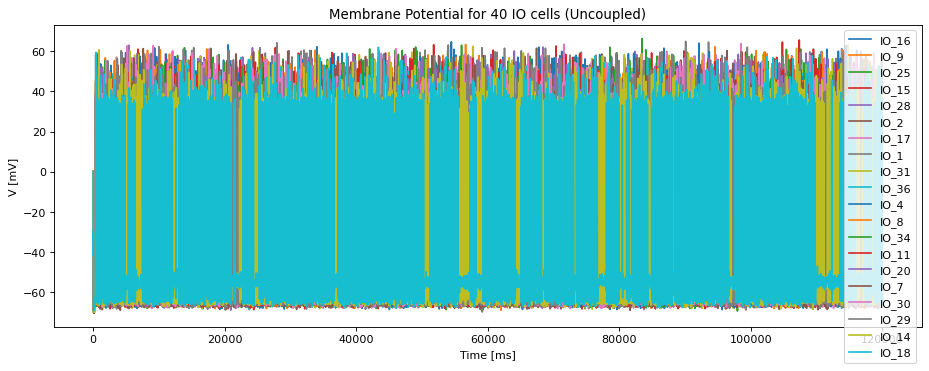

In [8]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in IO_PC_Synapse_Sources:#range(0,N_Cells_DCN):
    plot(IO_Statemon.t/ms,IO_Statemon.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_DCN)+" IO cells (Uncoupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()

WARNING    /Users/eliasmateofernandezsantoro/Python/miniconda3/lib/python3.8/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
 [py.warnings]
  fig.canvas.print_figure(bytes_io, **kw)



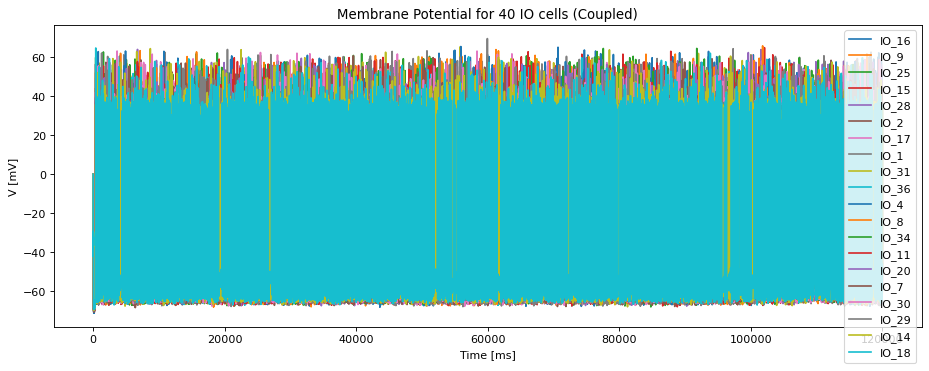

In [9]:
plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
for ii in IO_PC_Synapse_Sources:#range(0,N_Cells_DCN):
    plot(IO_Statemon_Coupled.t/ms,IO_Statemon_Coupled.Vs[ii]/mV, label='IO_'+str(ii+1))
title('Membrane Potential for '+str(N_Cells_DCN)+" IO cells (Coupled)")
ylabel('V [mV]')
xlabel('Time [ms]')
legend()
show()